### 注意力增强的Resnet18-SVM

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn import svm
from torchvision import transforms, datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 加载预训练的ResNet-18模型
resnet = models.resnet18(pretrained=True)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 4)
resnet.load_state_dict(torch.load('C:/Users/WHS/Desktop/SVM-Image-Classification-master/resnet18.pth'))   #加载训练完保存好的模型
resnet = nn.Sequential(*list(resnet.children())[:-1])  # 去掉最后的全连接层

# 加载数据集并提取特征
def extract_features(data_loader):
    feature_vectors = []
    labels = []
    for images, target in data_loader:
        # 提取图像特征
        features = resnet(images)
        features = features.view(features.size(0), -1)
        
        # 添加到特征向量列表和标签列表
        feature_vectors.append(features.detach())
        labels.append(target)

    feature_vectors = torch.cat(feature_vectors)
    labels = torch.cat(labels)
    return feature_vectors, labels

# 定义数据预处理
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
test_data_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)

# 提取训练数据的特征向量和标签
train_features, train_labels = extract_features(train_data_loader)
start_time = time.time()

# 自适应特征选择
selector = SelectKBest(score_func=mutual_info_classif, k=100)  # 选择100个最相关的特征
train_features_selected = selector.fit_transform(train_features, train_labels)

# 训练SVM分类器
svm_classifier = svm.SVC()
svm_classifier.fit(train_features_selected, train_labels)
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

start_time = time.time()
# 提取测试数据的特征向量和标签

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_data_loader= torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

test_features, test_labels = extract_features(test_data_loader)

# 应用特征选择器到测试数据
test_features_selected = selector.transform(test_features)

# 在选择的特征上进行分类
predicted_labels = svm_classifier.predict(test_features_selected)

# 计算分类准确率
accuracy = accuracy_score(test_labels, predicted_labels)
print("分类准确率：", accuracy)
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(test_labels))

1.5205373764038086
分类准确率： 0.85
0.023371057850973948


In [4]:
import joblib
joblib.dump(svm_classifier, 'svm_model.pkl')

['svm_model.pkl']

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('adaptive_resnet_svm_con.png', dpi=300)
    plt.tight_layout()

In [3]:
cnf_matrix = confusion_matrix(test_labels, predicted_labels)
print(cnf_matrix)

[[62  3  1  4]
 [13 55  1  1]
 [ 1  2 67  0]
 [ 7  1  3 59]]


Normalized confusion matrix
[[0.88571429 0.04285714 0.01428571 0.05714286]
 [0.18571429 0.78571429 0.01428571 0.01428571]
 [0.01428571 0.02857143 0.95714286 0.        ]
 [0.1        0.01428571 0.04285714 0.84285714]]


<ipython-input-2-16db82853134>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


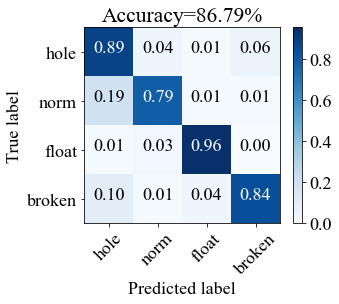

In [4]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_labels, predicted_labels)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)